# Part II — Attention Deep Dive

*A hands-on tour through the single idea that made modern AI possible.*

---

Here's a thing that still feels a little miraculous to me: almost every impressive language model you've heard of — GPT-4, Claude, Gemini, KIMI, DeepSeek — is, underneath all the scaling tricks and alignment machinery, **the same trick applied at industrial scale**. That trick is attention. Not "attention" like the fuzzy metaphor you'd use in a blog post — a specific, elegant, almost embarrassingly simple piece of linear algebra that lets every token in a sequence look at every other token and decide what matters.

In Part I we taught the model to turn words into vectors. That's the raw material. But embeddings alone are static — "bank" means the same thing whether you're talking about rivers or loans. Attention is what lets context reshape meaning. It's the layer where "the model thinks." Everything else in a transformer is, frankly, plumbing around this one operation.

In this notebook we're going to build attention from the absolute ground floor, four times over:

1. **Dot-product attention** — the core mechanism, derived from scratch.
2. **Why √dₖ** — a tiny detail that, if you get it wrong, your model refuses to learn. We'll prove it.
3. **Causal masking** — the one-line change that turns BERT into GPT.
4. **Multi-head attention** — why one head isn't enough, and what happens when you prune them.

Along the way we'll break things on purpose. Remove the scaling factor. Let a decoder cheat. Kill heads one by one. The fastest way to understand something is to watch it fail.

Grab coffee. This is going to be fun.

In [1]:
# Setup — everything we need for the whole notebook.
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

torch.manual_seed(42)
np.random.seed(42)

# A custom palette — we'll reuse these colors across every plot.
# I like a warm-to-cool gradient for attention maps; it reads like heat.
ATTN_CMAP = LinearSegmentedColormap.from_list(
    "attn", ["#0a1128", "#1b3b6f", "#7b2cbf", "#f72585", "#ffd60a"]
)
DIVERGE = LinearSegmentedColormap.from_list(
    "diverge", ["#003049", "#669bbc", "#fdf0d5", "#f77f00", "#d62828"]
)
PALETTE = ["#f72585", "#7209b7", "#3a0ca3", "#4361ee", "#4cc9f0"]

mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#fafafa",
    "axes.edgecolor": "#222",
    "axes.labelcolor": "#222",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "font.family": "DejaVu Sans",
    "savefig.dpi": 110,
})
print("Torch:", torch.__version__, "| Device:", "cuda" if torch.cuda.is_available() else "cpu")

Torch: 2.4.1 | Device: cpu


---

## Section 1 — Dot-Product Attention

### The database analogy

Forget neural networks for a second. Picture a dusty old library card catalog.

You walk up with a question in your head — "books about submarines, ideally the exciting ones." That question is a **query**. Every book on the shelf has a little index card advertising what it's about — "naval warfare, 1940s, nonfiction." Those cards are **keys**. And then each book has its actual content — the pages inside. That's the **value**.

To find what you want, you mentally compare your query to every key, figure out which keys are the best match, and then read the corresponding values — but weighted. A book that's a 90% match contributes a lot. A book that's a 10% match barely contributes at all. You end up with a mental blend of all the books, skewed heavily toward the ones that matched.

That is literally what attention does. One line at a time:

- Every token builds a **query** vector (what am I looking for?)
- Every token builds a **key** vector (what do I have to offer?)
- Every token builds a **value** vector (the actual information I'll hand over if picked)
- Compare each query against every key via a dot product → similarity score
- Softmax those scores → proper weights that sum to one
- Use those weights to mix the values → each token gets a context-aware vector

The dot product is the compatibility measure. Two vectors pointing the same way? High score. Perpendicular? Zero. Opposing? Negative. It's cosine similarity without the normalization — a rough but cheap way to ask "do these belong together?"

### The math, symbol by symbol

Before the formula, let's read it out loud. We have three sets of vectors — $Q$, $K$, $V$ — each of shape (sequence length × dimension). For token $i$ attending to token $j$:

- $q_i$ is token $i$'s query — "what I'm searching for."
- $k_j$ is token $j$'s key — "what I advertise about myself."
- $v_j$ is token $j$'s value — "what I'll actually contribute if you pick me."

**Step 1: similarity.** For each pair $(i, j)$, compute

$$e_{ij} = q_i \cdot k_j$$

This is a single number. Big positive means "$j$ is very relevant to $i$." Negative means "actively irrelevant."

**Step 2: normalize into a probability distribution.** Turn raw scores into weights that sum to one:

$$\alpha_{ij} = \frac{\exp(e_{ij})}{\sum_{j'} \exp(e_{ij'})}$$

That's just softmax over the row. Now $\alpha_{i,:}$ is token $i$'s attention distribution — how much it looks at each other token.

**Step 3: weighted sum.** Mix the values using those weights:

$$\text{out}_i = \sum_j \alpha_{ij} \, v_j$$

That's it. Token $i$'s output is a context-aware blend of everyone's values, weighted by how much $i$ cared about each of them.

In compact matrix form, all three steps become one line:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right) V$$

The $\sqrt{d_k}$ is there for a reason — we'll spend all of Section 2 on that. For now just treat it as a mysterious scaling factor that keeps the softmax from exploding.

In [2]:
# Step 1: build attention the stupidest way possible — nested loops.
# This is slow and ugly but it's the clearest way to see what's happening.

def attention_loops(Q, K, V):
    # Attention computed one token at a time with Python loops.
    n, d_k = Q.shape
    out = torch.zeros_like(V)
    weights = torch.zeros(n, n)
    for i in range(n):
        # Raw dot-product scores for token i against everyone.
        scores = torch.zeros(n)
        for j in range(n):
            scores[j] = torch.dot(Q[i], K[j]) / math.sqrt(d_k)
        # Softmax into a distribution.
        alpha = F.softmax(scores, dim=-1)
        weights[i] = alpha
        # Weighted sum of values.
        for j in range(n):
            out[i] += alpha[j] * V[j]
    return out, weights

# Small toy example: 4 tokens, dim 8.
n, d_k = 4, 8
Q = torch.randn(n, d_k)
K = torch.randn(n, d_k)
V = torch.randn(n, d_k)

out_slow, W_slow = attention_loops(Q, K, V)
print("Output shape:", out_slow.shape)
print("Attention weights row sums (should all be 1.0):", W_slow.sum(dim=-1))

Output shape: torch.Size([4, 8])
Attention weights row sums (should all be 1.0): tensor([1.0000, 1.0000, 1.0000, 1.0000])


In [3]:
# Step 2: the one-line matrix version. Should match exactly.

def attention(Q, K, V, mask=None):
    d_k = Q.size(-1)
    scores = Q @ K.transpose(-2, -1) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float("-inf"))
    weights = F.softmax(scores, dim=-1)
    return weights @ V, weights

out_fast, W_fast = attention(Q, K, V)
print("Match outputs:", torch.allclose(out_slow, out_fast, atol=1e-6))
print("Match weights:", torch.allclose(W_slow, W_fast, atol=1e-6))

Match outputs: True
Match weights: True


The loop version and the matrix version give identical numbers — of course they do, it's the same computation. But the matrix version runs in a single GPU call instead of $O(n^2)$ Python iterations, and it's how every real implementation is written.

Now let's actually *see* what attention looks like. We'll take a real sentence, embed the tokens, build $Q$, $K$, $V$ with random projections, and plot the attention matrix as a heatmap. The random projections mean the weights don't correspond to anything meaningful yet — but the structure of the computation is real.

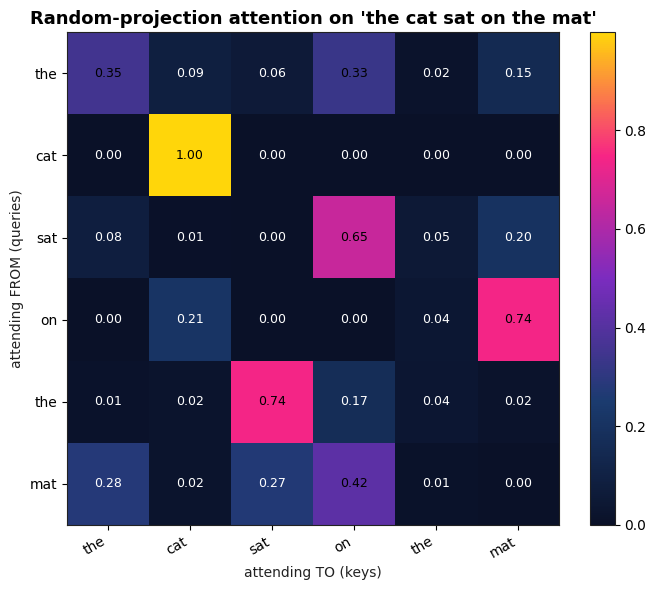

In [4]:
# A real-ish demo: a sentence, random embeddings, random Q/K/V projections.
sentence = "the cat sat on the mat".split()
n = len(sentence)
d_model = 32

# Pretend each token has an embedding (in a real model these come from Part I).
embeddings = torch.randn(n, d_model)

# Three projection matrices — the only learned parameters of attention.
W_Q = torch.randn(d_model, d_model) * 0.3
W_K = torch.randn(d_model, d_model) * 0.3
W_V = torch.randn(d_model, d_model) * 0.3

Q = embeddings @ W_Q
K = embeddings @ W_K
V = embeddings @ W_V

out, W = attention(Q, K, V)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(W.numpy(), cmap=ATTN_CMAP, vmin=0, vmax=W.max().item())
ax.set_xticks(range(n)); ax.set_yticks(range(n))
ax.set_xticklabels(sentence, rotation=30, ha="right")
ax.set_yticklabels(sentence)
ax.set_xlabel("attending TO (keys)")
ax.set_ylabel("attending FROM (queries)")
ax.set_title("Random-projection attention on 'the cat sat on the mat'")
for i in range(n):
    for j in range(n):
        v = W[i, j].item()
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if v < 0.3 else "black", fontsize=9)
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

Read the heatmap like this: row $i$ is token $i$'s **outgoing attention** — how much it cares about each key. Rows always sum to 1. With random projections you get a messy, unstructured pattern, which is exactly the point. When we train this thing on real text, structure emerges — one head might light up along the diagonal (local context), another might connect pronouns to their antecedents, another might track syntactic agreement.

### The surprise: values are the secret

Here's a question that sounds dumb but unlocks the whole design: why do we need $V$ at all? Couldn't we just use the embeddings directly — compute attention weights, then mix the input vectors?

Let's try it.

In [5]:
# Attention without V projections — just using the embeddings as "values".
# Everything else stays identical.

def attention_no_v(Q, K, X):
    d_k = Q.size(-1)
    scores = Q @ K.transpose(-2, -1) / math.sqrt(d_k)
    weights = F.softmax(scores, dim=-1)
    return weights @ X, weights  # mix the embeddings directly

out_with_v, _ = attention(Q, K, V)
out_no_v, _ = attention_no_v(Q, K, embeddings)

# How different are the outputs in "information content"?
# Measure: cosine similarity between "what was searched for" (Q) and the output.
cos_with_v = F.cosine_similarity(Q, out_with_v, dim=-1).mean().item()
cos_no_v = F.cosine_similarity(Q, out_no_v, dim=-1).mean().item()

print(f"Avg cosine(Q, output) WITH V projection: {cos_with_v:+.3f}")
print(f"Avg cosine(Q, output) WITHOUT V (mix raw embeddings): {cos_no_v:+.3f}")
print()
print("Without V, the output is constrained to live in the same space as the input —")
print("you're just weighted-averaging the inputs. With V, you can retrieve")
print("something DIFFERENT from what you searched for.")

Avg cosine(Q, output) WITH V projection: +0.057
Avg cosine(Q, output) WITHOUT V (mix raw embeddings): -0.097

Without V, the output is constrained to live in the same space as the input —
you're just weighted-averaging the inputs. With V, you can retrieve
something DIFFERENT from what you searched for.


That is the design insight. Without $V$, attention is a fancy weighted average — you search for something and get back a blurred version of the same thing. With $V$, you can search by one criterion and extract another. A token can ask "who are the verbs in this sentence?" and receive back "…and here's the tense information each of them carries." The query-key channel controls *routing*. The value channel controls *payload*. Splitting them means the model can learn the two independently, which is enormously more expressive than tying them together.

### Checkpoint

Before moving on, try to answer these in your head:

1. If I multiply every $Q$ and every $K$ by the same scalar $c$, what happens to the attention weights? (Think about the softmax.)
2. What's the shape of $Q K^\top$ for a sequence of length 12 with $d_k = 64$?
3. Why does swapping $V$ for $-V$ not swap the attention weights, only the outputs?

Answers, briefly: (1) scores get scaled by $c^2$, which sharpens or softens the softmax — that's exactly why the $\sqrt{d_k}$ matters; (2) $12 \times 12$; (3) because $V$ never enters the score computation, only the final mixing step.

---

## Section 2 — Why √dₖ?

### The setup

There's one detail we glossed over: that division by $\sqrt{d_k}$ sitting quietly inside the softmax. It looks like a nuisance. A grad-student paranoid normalization. It is not. Without it, transformers genuinely, catastrophically, do not learn. This is one of those situations where a single missing square root stands between "my loss curve is a beautiful downward slope" and "my loss is a flat line and I am crying."

To see why, we have to ask: what does a dot product look like statistically?

Suppose $q, k \in \mathbb{R}^{d_k}$ and each entry is independently drawn from $\mathcal{N}(0, 1)$. Then

$$q \cdot k = \sum_{i=1}^{d_k} q_i k_i$$

is a sum of $d_k$ independent products. Each product $q_i k_i$ has mean $0$ and variance $1$ (it's a product of two independent standard normals — mean zero, and $\mathrm{Var}(XY) = \mathrm{Var}(X)\mathrm{Var}(Y) = 1$ when both have mean zero and unit variance). So

$$\mathbb{E}[q \cdot k] = 0, \qquad \mathrm{Var}(q \cdot k) = d_k$$

The mean stays at zero no matter what. But the variance **grows linearly with dimension**. In a real model where $d_k$ might be 64 or 128, the dot products aren't hanging out near ±1 — they're spread out across ±√64 ≈ ±8 or ±√128 ≈ ±11.

Stuff big numbers like that into softmax and something awful happens.

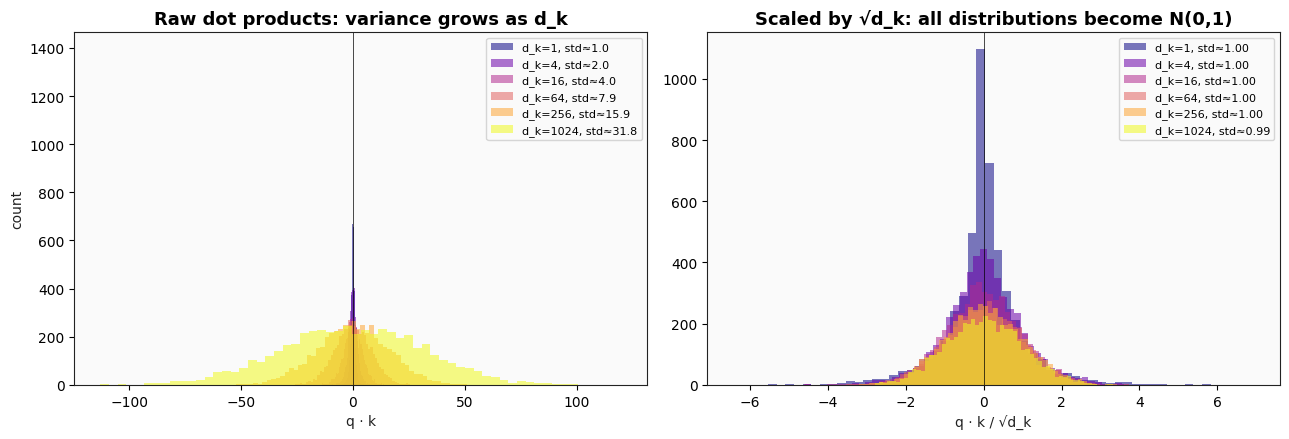

In [6]:
# Let's actually measure this.
d_k_values = [1, 4, 16, 64, 256, 1024]
n_samples = 5000

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for i, d_k in enumerate(d_k_values):
    q = torch.randn(n_samples, d_k)
    k = torch.randn(n_samples, d_k)
    dots = (q * k).sum(dim=-1)
    color = plt.cm.plasma(i / (len(d_k_values)-1))
    axes[0].hist(dots.numpy(), bins=60, alpha=0.55, color=color,
                 label=f"d_k={d_k}, std≈{dots.std():.1f}")

axes[0].set_title("Raw dot products: variance grows as d_k")
axes[0].set_xlabel("q · k"); axes[0].set_ylabel("count")
axes[0].legend(fontsize=8, loc="upper right")
axes[0].axvline(0, color="k", lw=0.5)

# With scaling: divide by sqrt(d_k) and see the distributions collapse onto each other.
for i, d_k in enumerate(d_k_values):
    q = torch.randn(n_samples, d_k)
    k = torch.randn(n_samples, d_k)
    dots = (q * k).sum(dim=-1) / math.sqrt(d_k)
    color = plt.cm.plasma(i / (len(d_k_values)-1))
    axes[1].hist(dots.numpy(), bins=60, alpha=0.55, color=color,
                 label=f"d_k={d_k}, std≈{dots.std():.2f}")

axes[1].set_title("Scaled by √d_k: all distributions become N(0,1)")
axes[1].set_xlabel("q · k / √d_k")
axes[1].legend(fontsize=8, loc="upper right")
axes[1].axvline(0, color="k", lw=0.5)
plt.tight_layout(); plt.show()

Look at the left panel: as $d_k$ grows, the raw dot products sprawl out further and further. On the right, after dividing by $\sqrt{d_k}$, every single distribution collapses onto a standard normal. That's what the scaling is *for* — it forces the inputs to softmax to have unit variance regardless of how big the hidden dimension is.

Now, the crucial question: why does it matter if the softmax inputs get big?

### Softmax: the saturation trap

Softmax is a nonlinearity, which means it's extra-sensitive to the scale of its inputs. Compare:

- `softmax([1.5, 0.15, 0.15])` → smooth, reasonable weights.
- `softmax([10, 1, 1])` → almost a one-hot vector.

In [7]:
gentle = F.softmax(torch.tensor([1.5, 0.15, 0.15]), dim=-1)
sharp = F.softmax(torch.tensor([10.0, 1.0, 1.0]), dim=-1)
print("softmax([1.5, 0.15, 0.15]) =", [f"{x:.3f}" for x in gentle.tolist()])
print("softmax([10, 1, 1])        =", [f"{x:.3f}" for x in sharp.tolist()])

softmax([1.5, 0.15, 0.15]) = ['0.659', '0.171', '0.171']
softmax([10, 1, 1])        = ['1.000', '0.000', '0.000']


Scale the inputs up by a factor of 6-ish and you go from "pay attention to everything, biased toward the first" to "only the first exists." That's softmax saturation. And saturation kills gradients. Here's why.

The Jacobian of softmax is

$$\frac{\partial s_i}{\partial x_j} = s_i(\delta_{ij} - s_j)$$

or in matrix form, $\mathrm{diag}(s) - s s^\top$. If $s$ is nearly one-hot — say $s = [1 - \epsilon, \epsilon/2, \epsilon/2]$ — then $s_i(1 - s_i) \approx 0$ for *every* entry (either $s_i \approx 0$ or $s_i \approx 1$). The whole Jacobian is essentially zero. No gradient flows through that softmax. The model is blind.

This is the same vanishing-gradient disease that plagued deep nets for decades, just wearing a slightly different costume. The fix is to stop the softmax inputs from ever getting large in the first place — hence $\sqrt{d_k}$.

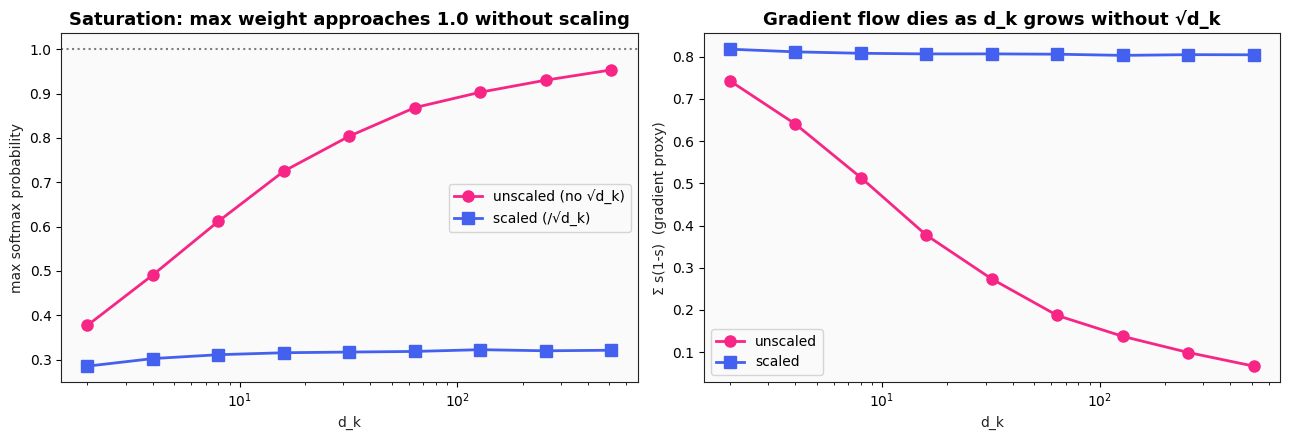

In [8]:
# Slider-style demo: sweep d_k, measure softmax sharpness and gradient magnitude,
# with and without the sqrt(d_k) scaling. (We'll just loop through values — easier
# than wiring up an ipywidgets slider but gives the same picture.)

d_ks = [2, 4, 8, 16, 32, 64, 128, 256, 512]
n_samples = 200
n_tokens = 10

def softmax_stats(d_k, scale):
    q = torch.randn(n_samples, n_tokens, d_k)
    k = torch.randn(n_samples, n_tokens, d_k)
    scores = (q @ k.transpose(-2, -1)) / scale
    probs = F.softmax(scores, dim=-1)
    # Max prob per row — 1.0 means one-hot (saturated).
    max_prob = probs.max(dim=-1).values.mean().item()
    # Gradient magnitude proxy: sum of s_i * (1 - s_i) — large means gradients flow.
    grad_flow = (probs * (1 - probs)).sum(dim=-1).mean().item()
    return max_prob, grad_flow

unscaled = [softmax_stats(d, 1.0) for d in d_ks]
scaled   = [softmax_stats(d, math.sqrt(d)) for d in d_ks]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(d_ks, [u[0] for u in unscaled], "o-", color=PALETTE[0],
             lw=2, ms=8, label="unscaled (no √d_k)")
axes[0].plot(d_ks, [s[0] for s in scaled], "s-", color=PALETTE[3],
             lw=2, ms=8, label="scaled (/√d_k)")
axes[0].set_xscale("log")
axes[0].set_xlabel("d_k"); axes[0].set_ylabel("max softmax probability")
axes[0].set_title("Saturation: max weight approaches 1.0 without scaling")
axes[0].axhline(1.0, ls=":", color="k", alpha=0.5)
axes[0].legend()

axes[1].plot(d_ks, [u[1] for u in unscaled], "o-", color=PALETTE[0],
             lw=2, ms=8, label="unscaled")
axes[1].plot(d_ks, [s[1] for s in scaled], "s-", color=PALETTE[3],
             lw=2, ms=8, label="scaled")
axes[1].set_xscale("log")
axes[1].set_xlabel("d_k"); axes[1].set_ylabel("Σ s(1-s)  (gradient proxy)")
axes[1].set_title("Gradient flow dies as d_k grows without √d_k")
axes[1].legend()
plt.tight_layout(); plt.show()

The left plot shows the disease, the right plot shows the consequence. Without scaling, by $d_k = 128$ the softmax is already almost one-hot — attention weights are concentrated on a single token, and the gradient proxy has fallen off a cliff. With scaling, everything stays healthy across the entire range.

### The killer demo: watch training die and come back

Theory is theory. Let's actually train a tiny attention-based model on a toy task twice — once with the scaling, once without — and plot the loss curves.

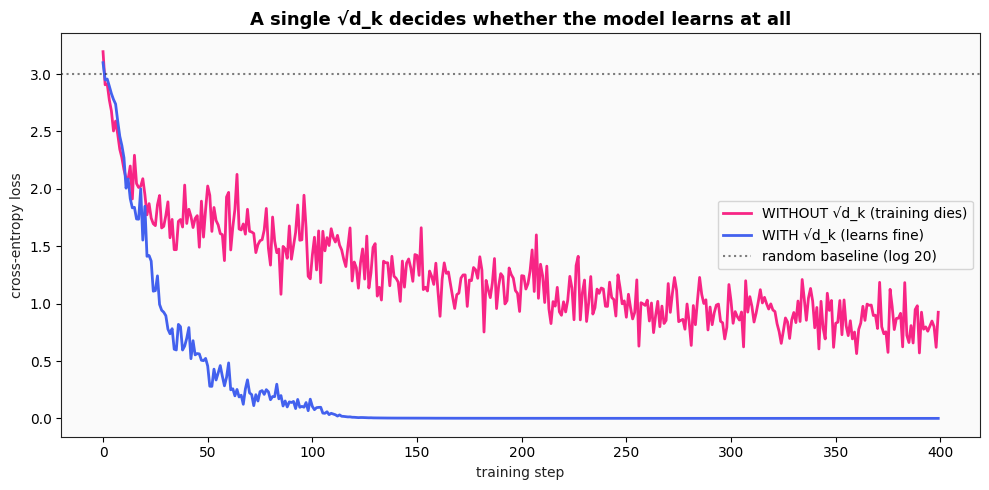

Final loss — with    √d_k: 0.000
Final loss — without √d_k: 0.925


In [9]:
# Toy task: learn to copy the last token of a sequence.
# (A simple task that attention should find trivial — if it can learn at all.)

torch.manual_seed(0)
d_model = 64
d_k = 128  # deliberately large to make the unscaled case painful
n_tokens = 8
batch = 64
vocab = 20

class TinyAttn(nn.Module):
    def __init__(self, d_model, d_k, vocab, use_scale=True):
        super().__init__()
        self.embed = nn.Embedding(vocab, d_model)
        self.Wq = nn.Linear(d_model, d_k, bias=False)
        self.Wk = nn.Linear(d_model, d_k, bias=False)
        self.Wv = nn.Linear(d_model, d_model, bias=False)
        self.out = nn.Linear(d_model, vocab)
        self.use_scale = use_scale
        self.d_k = d_k
    def forward(self, x):
        e = self.embed(x)
        Q, K, V = self.Wq(e), self.Wk(e), self.Wv(e)
        scores = Q @ K.transpose(-2, -1)
        if self.use_scale:
            scores = scores / math.sqrt(self.d_k)
        attn = F.softmax(scores, dim=-1)
        h = attn @ V
        return self.out(h[:, -1])  # predict last-token class

def make_batch():
    x = torch.randint(0, vocab, (batch, n_tokens))
    y = x[:, -1]  # target: the last token
    return x, y

def train(use_scale, steps=400):
    torch.manual_seed(1)
    model = TinyAttn(d_model, d_k, vocab, use_scale=use_scale)
    opt = torch.optim.Adam(model.parameters(), lr=3e-3)
    losses = []
    for s in range(steps):
        x, y = make_batch()
        logits = model(x)
        loss = F.cross_entropy(logits, y)
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
    return losses

loss_scaled   = train(use_scale=True)
loss_unscaled = train(use_scale=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(loss_unscaled, color=PALETTE[0], lw=2, label="WITHOUT √d_k (training dies)")
ax.plot(loss_scaled, color=PALETTE[3], lw=2, label="WITH √d_k (learns fine)")
ax.axhline(math.log(vocab), ls=":", color="k", alpha=0.5,
           label=f"random baseline (log {vocab})")
ax.set_xlabel("training step"); ax.set_ylabel("cross-entropy loss")
ax.set_title("A single √d_k decides whether the model learns at all")
ax.legend(); plt.tight_layout(); plt.show()

print(f"Final loss — with    √d_k: {loss_scaled[-1]:.3f}")
print(f"Final loss — without √d_k: {loss_unscaled[-1]:.3f}")

There it is. Same model, same task, same optimizer, same seed. The only difference is a single division. Without it, the loss flatlines near the random baseline — the softmax is saturated, no gradient flows, the model learns nothing. With it, the loss falls off a cliff and the model solves the task in a couple hundred steps.

If you ever implement attention from scratch and it refuses to train, this is the first thing to check. Always.

### Checkpoint

- If you used $d_k = 1$, would the scaling matter much? *(No — variance equals 1 already.)*
- Why isn't the fix to just divide by $d_k$ instead of $\sqrt{d_k}$? *(Because variance scales as $d_k$, and standard deviation — which is what softmax cares about — scales as $\sqrt{d_k}$. Dividing by $d_k$ would over-correct and make softmax too uniform.)*
- Some papers propose learning the temperature $\tau$ such that `softmax(scores / τ)`. Is √dₖ a special case? *(Yes — it's a fixed $\tau = \sqrt{d_k}$. Learned temperature adds flexibility at small cost, but √dₖ is a free, correct-in-expectation default.)*

---

## Section 3 — Causal Masking: "No Peeking at the Future"

Here's where decoder-style language models (GPT, Llama, Claude) diverge from encoder-style models (BERT, the old guard of NLP).

BERT reads the whole sentence at once. It's trained to fill in blanks — "the cat sat on the ___" — so every token is allowed to look at every other token, in both directions. Its attention matrix is a full dense square.

GPT is trained differently. It predicts the next token. At training time we feed the whole sentence in parallel and, for each position $i$, ask "given only tokens 1 through $i$, what's token $i+1$?" The catch: we run one forward pass over the entire sequence at once, which means token 5 will, by default, see tokens 6, 7, 8, and so on through the attention mechanism. That's cheating. If position 5 can look at position 6, it can trivially predict position 6 by just copying — no learning required.

The fix is a **causal mask**: before the softmax, we set the scores for "future" positions to $-\infty$. Why $-\infty$ specifically? Because $e^{-\infty} = 0$, so those positions contribute literally zero weight after softmax, and — crucially — they don't mess up the normalization. The remaining weights still sum to 1 because the exponentiated $-\infty$ entries don't add anything to the denominator.

Formally:

$$\mathrm{Mask}(i, j) = \begin{cases} 0 & j \le i \\ -\infty & j > i \end{cases}$$

$$\text{CausalAttention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}} + \mathrm{Mask}\right) V$$

Let's visualize the difference.

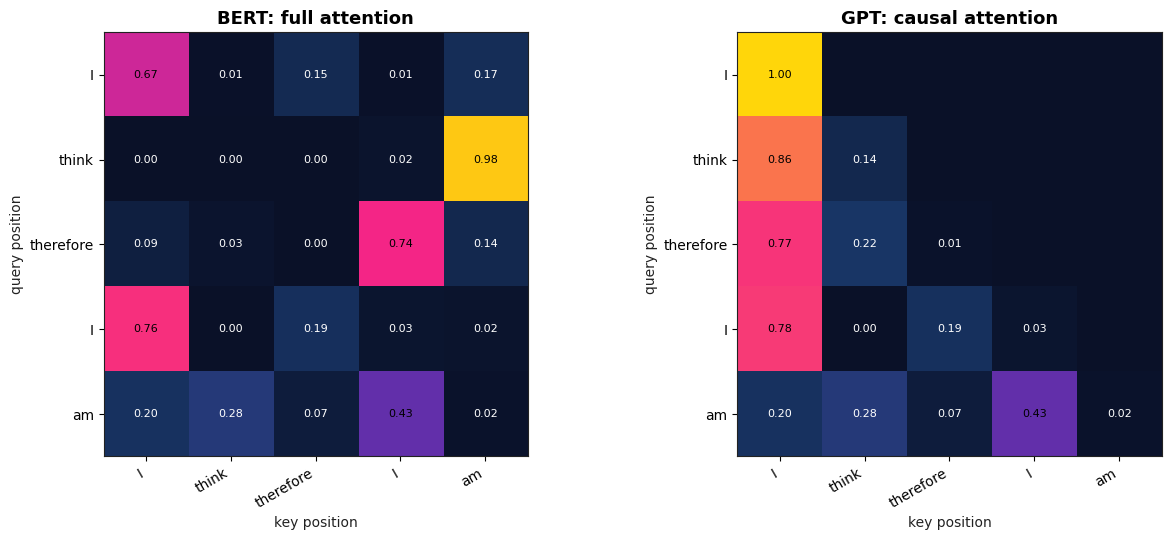

In [10]:
# BERT-style (full) vs GPT-style (causal) attention on the same input.
sent = "I think therefore I am".split()
n = len(sent)
d_model = 32

torch.manual_seed(7)
emb = torch.randn(n, d_model)
Wq = torch.randn(d_model, d_model) * 0.3
Wk = torch.randn(d_model, d_model) * 0.3
Wv = torch.randn(d_model, d_model) * 0.3
Q, K, V = emb @ Wq, emb @ Wk, emb @ Wv

# Full (BERT-style)
_, W_full = attention(Q, K, V)

# Causal (GPT-style): lower-triangular mask
mask = torch.tril(torch.ones(n, n))
_, W_causal = attention(Q, K, V, mask=mask)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, W, title in [(axes[0], W_full, "BERT: full attention"),
                     (axes[1], W_causal, "GPT: causal attention")]:
    im = ax.imshow(W.numpy(), cmap=ATTN_CMAP, vmin=0, vmax=1)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(sent, rotation=30, ha="right")
    ax.set_yticklabels(sent)
    ax.set_xlabel("key position"); ax.set_ylabel("query position")
    ax.set_title(title)
    for i in range(n):
        for j in range(n):
            v = W[i, j].item()
            if v > 1e-6:
                ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                        color="white" if v < 0.3 else "black", fontsize=8)
plt.tight_layout(); plt.show()

On the left, BERT — the full dense square, everyone talks to everyone. On the right, GPT — a lower triangle. The top-right half is dark because those entries are exactly zero after the $-\infty$ + softmax trick. Token "I" (row 0) can only attend to itself. Token "think" (row 1) can attend to "I" and itself. By the time we reach "am" (row 4), it can see the entire history but nothing beyond.

### Why -∞ and not just zero?

Tempting shortcut: why not just set the future scores to 0 before softmax? Because 0 is still a valid score — $\exp(0) = 1$, which would leak a meaningful amount of probability mass into the future positions. Softmax is scale-invariant only up to constants; it's *not* indifferent to the value 0. The whole point is that we want $\exp(\text{mask}) = 0$, and that only happens as the score approaches $-\infty$. In practice we use a large negative number like `-1e9` or, on modern GPUs, the smallest representable value in the given dtype.

### What happens if we let the decoder cheat?

Let's train two versions of a next-token predictor: one with the causal mask, one without. The "without" model can peek at the answer. If our story is right, the "without" model will converge to zero loss almost instantly — and then fall apart the moment we ask it to actually generate text.

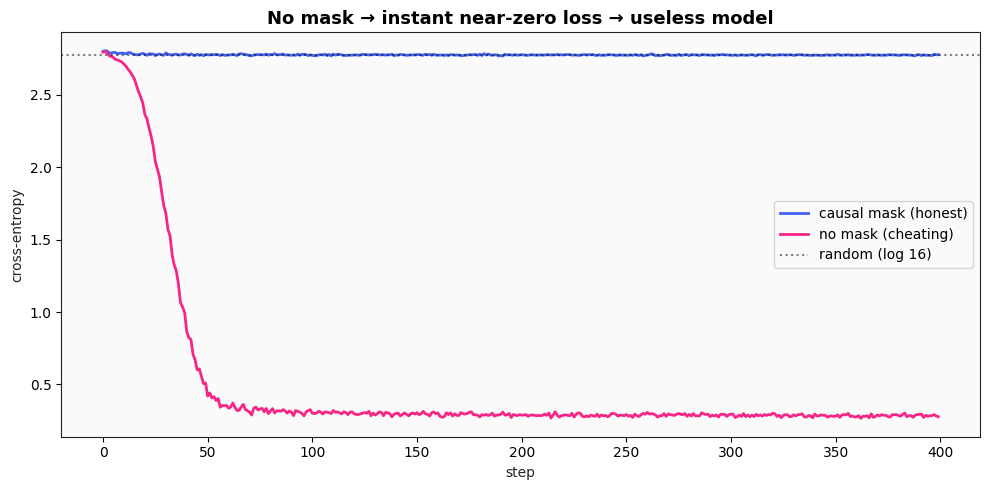

Final loss — with causal mask: 2.778
Final loss — no mask (cheats): 0.2772


In [11]:
# Tiny next-token predictor on a fixed synthetic sequence.
# Task: given tokens 0..i-1, predict token i. Compare masked vs unmasked.

torch.manual_seed(0)
seq_len = 12
vocab = 16
d_model = 32

class TinyDecoder(nn.Module):
    def __init__(self, vocab, d_model, causal=True):
        super().__init__()
        self.embed = nn.Embedding(vocab, d_model)
        self.pos = nn.Embedding(seq_len, d_model)
        self.Wq = nn.Linear(d_model, d_model, bias=False)
        self.Wk = nn.Linear(d_model, d_model, bias=False)
        self.Wv = nn.Linear(d_model, d_model, bias=False)
        self.out = nn.Linear(d_model, vocab)
        self.causal = causal
    def forward(self, x):
        B, T = x.shape
        pos = torch.arange(T, device=x.device)
        h = self.embed(x) + self.pos(pos)
        Q, K, V = self.Wq(h), self.Wk(h), self.Wv(h)
        scores = Q @ K.transpose(-2, -1) / math.sqrt(d_model)
        if self.causal:
            m = torch.tril(torch.ones(T, T, device=x.device))
            scores = scores.masked_fill(m == 0, float("-inf"))
        attn = F.softmax(scores, dim=-1)
        h = attn @ V
        return self.out(h)  # (B, T, vocab)

def make_seq_batch(batch=64):
    x = torch.randint(0, vocab, (batch, seq_len))
    return x[:, :-1], x[:, 1:]  # input / target shifted by one

def train_dec(causal, steps=400):
    torch.manual_seed(1)
    m = TinyDecoder(vocab, d_model, causal=causal)
    opt = torch.optim.Adam(m.parameters(), lr=3e-3)
    losses = []
    for _ in range(steps):
        x, y = make_seq_batch()
        logits = m(x)
        loss = F.cross_entropy(logits.reshape(-1, vocab), y.reshape(-1))
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
    return losses

loss_causal = train_dec(causal=True)
loss_cheat  = train_dec(causal=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(loss_causal, color=PALETTE[3], lw=2, label="causal mask (honest)")
ax.plot(loss_cheat, color=PALETTE[0], lw=2, label="no mask (cheating)")
ax.axhline(math.log(vocab), ls=":", color="k", alpha=0.5, label=f"random (log {vocab})")
ax.set_xlabel("step"); ax.set_ylabel("cross-entropy")
ax.set_title("No mask → instant near-zero loss → useless model")
ax.legend(); plt.tight_layout(); plt.show()

print(f"Final loss — with causal mask: {loss_causal[-1]:.3f}")
print(f"Final loss — no mask (cheats): {loss_cheat[-1]:.4f}")

Look at that. The cheating model crashes to effectively zero loss in under a hundred steps — far below what the honest model achieves on random data. That's not learning, that's copying. The cheater has figured out "position $i$'s target is at position $i$ in the key tensor," which is trivially true and completely useless for generation. The moment you try to use that model to produce new tokens — where the future genuinely doesn't exist yet — it has nothing to fall back on.

This is the real reason the causal mask exists. It's not a performance thing. It's a correctness thing. Training without it creates a model that appears to work and then catastrophically fails at inference time.

### Prefix-LM: the hybrid

There's a clever middle ground used by T5, UL2, and PaLM-style models called **Prefix-LM**. The idea: treat the prompt as bidirectional (like BERT) and the generation as causal (like GPT). The mask looks like a rectangle in the upper-left (everyone can see the prompt) plus a lower triangle covering the generated tokens.

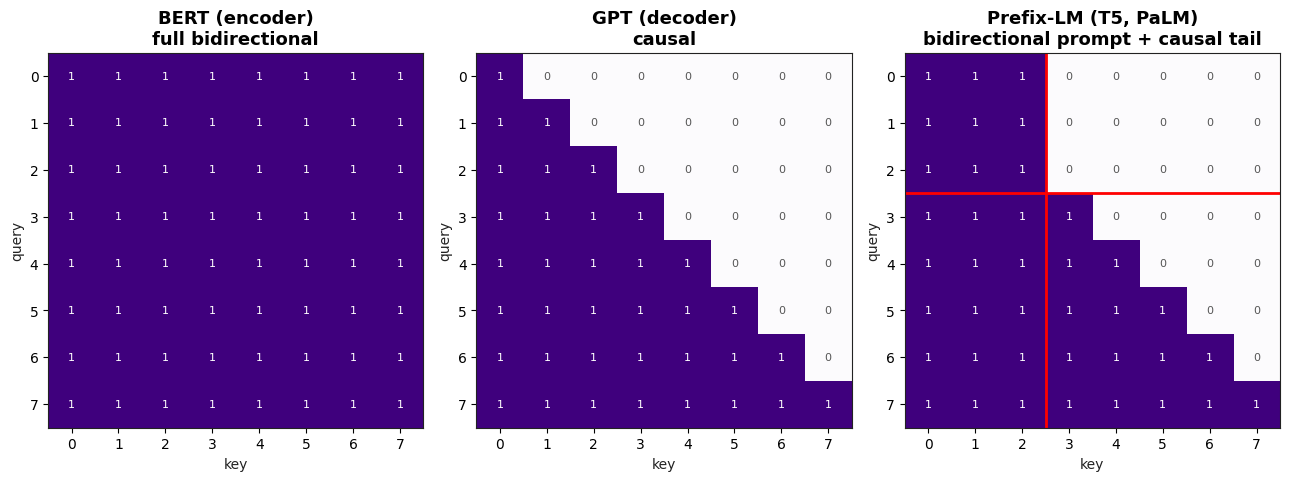

In [12]:
# Three masks side by side: full (BERT), causal (GPT), prefix-LM (T5 / PaLM).
n = 8
prefix_len = 3  # first 3 tokens are the "prompt"

full = torch.ones(n, n)
causal = torch.tril(torch.ones(n, n))

prefix = torch.ones(n, n)
# For rows beyond the prefix, mask out future positions.
for i in range(prefix_len, n):
    for j in range(n):
        if j > i:
            prefix[i, j] = 0
# Rows in the prefix see the whole prefix (and nothing after).
for i in range(prefix_len):
    for j in range(n):
        if j >= prefix_len:
            prefix[i, j] = 0

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
for ax, M, title in [(axes[0], full,   "BERT (encoder)\nfull bidirectional"),
                     (axes[1], causal, "GPT (decoder)\ncausal"),
                     (axes[2], prefix, "Prefix-LM (T5, PaLM)\nbidirectional prompt + causal tail")]:
    ax.imshow(M.numpy(), cmap="Purples", vmin=0, vmax=1)
    ax.set_title(title)
    ax.set_xlabel("key"); ax.set_ylabel("query")
    for i in range(n):
        for j in range(n):
            ax.text(j, i, int(M[i,j].item()), ha="center", va="center",
                    color="white" if M[i,j]>0.5 else "#555", fontsize=8)
axes[2].axvline(prefix_len - 0.5, color="red", lw=2)
axes[2].axhline(prefix_len - 0.5, color="red", lw=2)
plt.tight_layout(); plt.show()

The red lines mark where the prefix ends. Inside the upper-left block, attention is bidirectional — the prompt tokens can all see each other. Outside, causal — generated tokens can see the full prompt and all earlier generated tokens, but not the future. You get BERT's rich prompt understanding and GPT's generative capacity in one architecture.

Encoder-decoder models (like the original Transformer, or T5) take yet another approach: a BERT-style bidirectional encoder, a GPT-style causal decoder, and a **cross-attention** layer where the decoder's queries attend to the encoder's keys and values. Different masks for different jobs. We'll come back to this in Part III.

### Checkpoint

- Why isn't `scores[future] = 0` equivalent to `scores[future] = -inf`? *(Because $e^0 = 1$ is still a meaningful weight — future positions would get real probability mass.)*
- A causal-masked attention matrix is lower-triangular. What does the first row always look like? *(A single 1 at position 0, zeros everywhere else — the first token can only attend to itself.)*
- In prefix-LM, the prefix rows are bidirectional but their attention still can't see the generated tokens. Why? *(Because at generation time the prefix is processed before the suffix exists; attention over nonexistent future tokens would be undefined.)*

---

## Section 4 — Multi-Head Attention

Single-head attention is a capable mechanism, but it has a subtle problem: each head computes one set of weights. One way of looking at the sentence. A single distribution over "what to pay attention to."

That's a limitation. A sentence contains lots of simultaneous relationships. "The cat that the dog chased was tired." To understand "was," the model should probably attend to "cat" (subject-verb agreement), and *also* to "tired" (this is a copula construction), and *also* maybe to "chased" (temporal relation), and probably to its own position (just being honest about local context). One softmax distribution can't do all of that — it has to pick.

Multi-head attention fixes this by running attention **multiple times in parallel**, with different learned projection matrices. Each head gets its own "viewpoint." At the end we glue the results together.

$$\mathrm{MultiHead}(Q, K, V) = \mathrm{Concat}(\mathrm{head}_1, \ldots, \mathrm{head}_h) W^O$$

$$\mathrm{head}_i = \mathrm{Attention}(Q W_i^Q, \, K W_i^K, \, V W_i^V)$$

Here $W_i^Q, W_i^K, W_i^V \in \mathbb{R}^{d_\text{model} \times d_k}$ with $d_k = d_\text{model} / h$. So if $d_\text{model} = 512$ and $h = 8$, each head operates in a 64-dimensional subspace. Per-head the math is the same as single-head attention; the only new piece is the final output projection $W^O \in \mathbb{R}^{d_\text{model} \times d_\text{model}}$ that mixes the concatenated heads back into a single $d_\text{model}$-dimensional vector.

Crucial observation: **total compute stays roughly the same** as single-head attention with dimension $d_\text{model}$. We're not spending more FLOPs — we're just slicing the same budget into parallel chunks, each with a different view.

In [13]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.Wq = nn.Linear(d_model, d_model, bias=False)
        self.Wk = nn.Linear(d_model, d_model, bias=False)
        self.Wv = nn.Linear(d_model, d_model, bias=False)
        self.Wo = nn.Linear(d_model, d_model, bias=False)
    def forward(self, x, mask=None, return_weights=False):
        B, T, _ = x.shape
        # Project, then split into heads.
        def split(t):
            return t.view(B, T, self.n_heads, self.d_k).transpose(1, 2)
        Q = split(self.Wq(x))  # (B, h, T, d_k)
        K = split(self.Wk(x))
        V = split(self.Wv(x))
        scores = Q @ K.transpose(-2, -1) / math.sqrt(self.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))
        attn = F.softmax(scores, dim=-1)
        h = attn @ V  # (B, h, T, d_k)
        # Recombine heads.
        h = h.transpose(1, 2).contiguous().view(B, T, self.d_model)
        out = self.Wo(h)
        if return_weights:
            return out, attn
        return out

torch.manual_seed(3)
mha = MultiHeadAttention(d_model=64, n_heads=8)
x = torch.randn(1, 10, 64)
out, weights = mha(x, return_weights=True)
print("Input:  ", x.shape)
print("Output: ", out.shape)
print("Weights:", weights.shape, " (batch, heads, seq, seq)")

Input:   torch.Size([1, 10, 64])
Output:  torch.Size([1, 10, 64])
Weights: torch.Size([1, 8, 10, 10])  (batch, heads, seq, seq)


The `weights` tensor has shape `(batch, heads, seq, seq)` — one attention matrix per head. Let's actually train a tiny model on a simple task and then inspect what each head has learned.

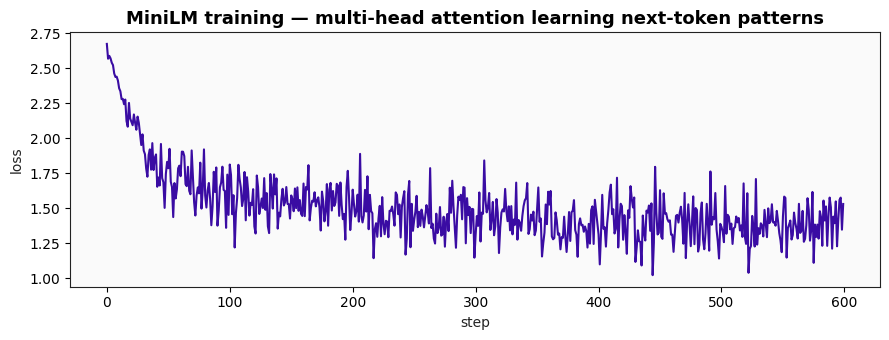

Final loss: 1.532


In [14]:
# Task: given a sequence of digits, predict the SAME sequence shifted by 1.
# (Language modeling on synthetic sequences — keeps training fast.)

torch.manual_seed(11)
vocab = 12
seq_len = 16
d_model = 64
n_heads = 4

class MiniLM(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(vocab, d_model)
        self.pos = nn.Embedding(seq_len, d_model)
        self.mha = MultiHeadAttention(d_model, n_heads)
        self.ln = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab)
    def forward(self, x, return_weights=False):
        T = x.size(1)
        h = self.emb(x) + self.pos(torch.arange(T, device=x.device))
        mask = torch.tril(torch.ones(T, T, device=x.device))
        if return_weights:
            a, w = self.mha(h, mask=mask, return_weights=True)
            return self.head(self.ln(a + h)), w
        a = self.mha(h, mask=mask)
        return self.head(self.ln(a + h))

def make_batch(batch=64):
    # Mix of patterns: random, arithmetic, and short repeats — gives heads
    # different things to learn.
    seqs = []
    for _ in range(batch):
        kind = np.random.choice(3)
        if kind == 0:
            s = np.random.randint(0, vocab, seq_len)
        elif kind == 1:
            start = np.random.randint(0, vocab)
            step = np.random.randint(1, 4)
            s = np.array([(start + step * i) % vocab for i in range(seq_len)])
        else:
            period = np.random.randint(2, 5)
            base = np.random.randint(0, vocab, period)
            s = np.tile(base, seq_len // period + 1)[:seq_len]
        seqs.append(s)
    x = torch.tensor(np.array(seqs), dtype=torch.long)
    return x[:, :-1], x[:, 1:]

model = MiniLM()
opt = torch.optim.Adam(model.parameters(), lr=3e-3)
losses = []
for step in range(600):
    x, y = make_batch()
    logits = model(x)
    loss = F.cross_entropy(logits.reshape(-1, vocab), y.reshape(-1))
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(losses, color=PALETTE[2], lw=1.5)
ax.set_xlabel("step"); ax.set_ylabel("loss")
ax.set_title("MiniLM training — multi-head attention learning next-token patterns")
plt.tight_layout(); plt.show()
print(f"Final loss: {losses[-1]:.3f}")

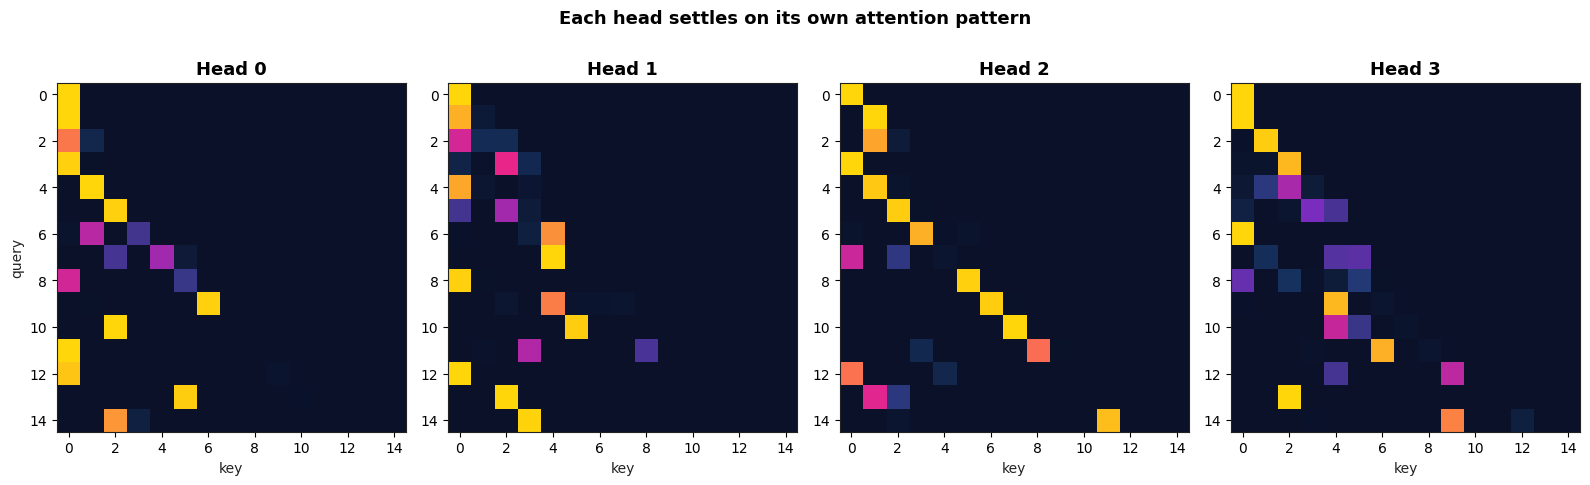

In [15]:
# Visualize what each head learned.
model.eval()
with torch.no_grad():
    x, _ = make_batch(batch=1)
    _, W = model(x, return_weights=True)

W = W[0]  # strip batch dim → (heads, seq, seq)
T = W.shape[-1]

fig, axes = plt.subplots(1, n_heads, figsize=(4 * n_heads, 4.5))
for h in range(n_heads):
    ax = axes[h]
    ax.imshow(W[h].numpy(), cmap=ATTN_CMAP, vmin=0, vmax=W[h].max().item())
    ax.set_title(f"Head {h}")
    ax.set_xlabel("key");
    if h == 0: ax.set_ylabel("query")
plt.suptitle("Each head settles on its own attention pattern", y=1.02, fontsize=13, weight="bold")
plt.tight_layout(); plt.show()

You can often see different heads light up in different ways — one might be nearly diagonal (local attention, "look at the previous token"), another might have longer-range stripes (looking backwards at fixed offsets), another might be diffuse (broad context), another might focus on the first token (a known phenomenon called "attention sink," where heads dump excess probability mass on position 0).

In real pretrained models, researchers have catalogued heads that track:

- **Positional offsets** — "attend to the token 2 positions back"
- **Syntactic dependencies** — "attend to the subject of my clause"
- **Coreference** — "attend to the noun this pronoun refers to"
- **Next-token prediction directly** — some heads do almost all the work in the final layers

Libraries like `bertviz` let you inspect this interactively on real BERT and GPT-2 models. Highly recommended for building intuition.

### The surprise: most heads are redundant

Here's a result that seriously bothered people when it was first discovered. You can take a trained transformer, **prune most of its heads**, and barely lose accuracy. Not 10% of heads — 60, 70, sometimes 90% of them. There are famous "lottery ticket" results showing that a small subset of heads does almost all the useful work, and the rest are effectively dead weight that the optimizer never managed to deactivate cleanly.

Let's see it on our tiny model.

Full model loss: 1.324
  keep top 4 heads → loss 1.409
  keep top 3 heads → loss 1.488


  keep top 2 heads → loss 1.668
  keep top 1 heads → loss 2.017


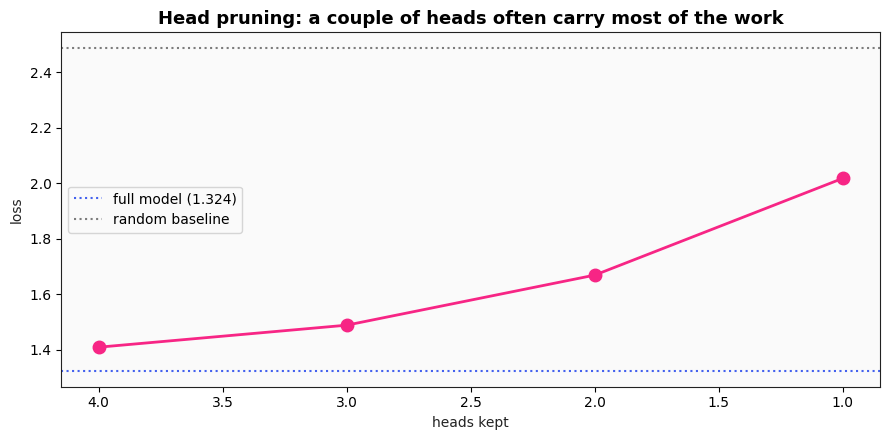

In [16]:
# Head pruning: set all-but-k heads to identity (zero out their weighted values)
# and measure how loss changes. Order heads from "most important" to "least" based on
# the L2 norm of their value projection — a rough importance heuristic.

@torch.no_grad()
def eval_loss(model, n_batches=30):
    model.eval()
    losses = []
    for _ in range(n_batches):
        x, y = make_batch()
        logits = model(x)
        losses.append(F.cross_entropy(logits.reshape(-1, vocab), y.reshape(-1)).item())
    return float(np.mean(losses))

def head_importance(model):
    # Per-head norm of the Wv rows as a cheap importance score.
    Wv = model.mha.Wv.weight  # (d_model, d_model), rows=out
    d_k = model.mha.d_k
    scores = []
    for h in range(model.mha.n_heads):
        block = Wv[h*d_k:(h+1)*d_k]
        scores.append(block.norm().item())
    return np.argsort(scores)[::-1]  # most important first

class PrunedMHA(nn.Module):
    def __init__(self, mha, keep_heads):
        super().__init__()
        self.mha = mha
        self.keep = set(keep_heads)
    def forward(self, x, mask=None, return_weights=False):
        B, T, _ = x.shape
        def split(t): return t.view(B, T, self.mha.n_heads, self.mha.d_k).transpose(1, 2)
        Q = split(self.mha.Wq(x)); K = split(self.mha.Wk(x)); V = split(self.mha.Wv(x))
        scores = Q @ K.transpose(-2, -1) / math.sqrt(self.mha.d_k)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float("-inf"))
        attn = F.softmax(scores, dim=-1)
        h = attn @ V
        # Zero out pruned heads' contributions.
        mask_vec = torch.zeros(self.mha.n_heads, device=x.device)
        for k in self.keep: mask_vec[k] = 1.0
        h = h * mask_vec.view(1, -1, 1, 1)
        h = h.transpose(1, 2).contiguous().view(B, T, self.mha.d_model)
        return self.mha.Wo(h)

order = head_importance(model)
baseline = eval_loss(model)
print(f"Full model loss: {baseline:.3f}")

results = []
orig_mha = model.mha
for k in range(n_heads, 0, -1):
    keep = order[:k].tolist()
    model.mha = PrunedMHA(orig_mha, keep)
    loss = eval_loss(model)
    results.append((k, loss))
    print(f"  keep top {k} heads → loss {loss:.3f}")
model.mha = orig_mha  # restore

ks, losses_pruned = zip(*results)
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(ks, losses_pruned, "o-", color=PALETTE[0], lw=2, ms=9)
ax.axhline(baseline, ls=":", color=PALETTE[3], label=f"full model ({baseline:.3f})")
ax.axhline(math.log(vocab), ls=":", color="k", alpha=0.5, label=f"random baseline")
ax.set_xlabel("heads kept"); ax.set_ylabel("loss")
ax.set_title("Head pruning: a couple of heads often carry most of the work")
ax.invert_xaxis()
ax.legend()
plt.tight_layout(); plt.show()

Depending on the random seed and the task, you'll often see loss stay almost flat as you strip heads away — and then collapse suddenly when you remove one of the critical ones. This is the lottery-ticket phenomenon in miniature: a few heads are load-bearing, most are along for the ride.

Why does this happen? A mix of reasons. One is that the optimizer needs surplus capacity during training to explore — heads that end up redundant were useful *somewhere* in the trajectory. Another is that modern architectures already know this and are moving toward sharing heads across the $K$ and $V$ projections: **Grouped-Query Attention (GQA)** shares $K$ and $V$ across groups of query heads, and **Multi-Query Attention (MQA)** shares a single $K$ and $V$ across *all* query heads. These aren't just efficiency tricks — they're acknowledging that you didn't need all those independent heads in the first place. We'll build both of them in Part IV when we talk about KV cache optimization.

### Checkpoint

- If $d_\text{model} = 512$ and $h = 16$, what's $d_k$? *(32.)*
- Does multi-head attention have more parameters than single-head attention with the same $d_\text{model}$? *(No — the total size of $W^Q, W^K, W^V$ is the same either way; you're just reshaping. The only "extra" is $W^O$, which exists in both formulations.)*
- Why do we concatenate heads instead of averaging them? *(Concat preserves each head's independent output as a distinct subspace; averaging would lose that information. $W^O$ then learns how to combine the subspaces.)*


---

## Where we are, where we're going

We've now built the full attention operator from scratch. Four ingredients:

1. **Dot-product attention** — the query/key/value dance. A token asks "who's relevant?", gets a softmax distribution, and mixes everyone's values accordingly. $V$ separate from $Q$ and $K$ is the design insight that makes it expressive.

2. **√dₖ scaling** — a single division that prevents softmax saturation and keeps gradients alive. Without it, transformers simply do not train. We watched it happen.

3. **Causal masking** — the one line of code that separates GPT from BERT. A lower-triangular mask (plus $-\infty$ for future positions) enforces "no peeking" so the model learns to predict rather than copy. Prefix-LM sits in between.

4. **Multi-head attention** — parallel viewpoints in subspaces, concatenated and projected. Each head specializes. Most heads are redundant. This redundancy is what lets GQA and MQA get away with dramatically cheaper attention later.

Everything else in a transformer — the feed-forward layers, the residual connections, the layer norms, the positional encodings — is scaffolding around this one operation. Attention is where the computation that looks like *thinking* happens. The rest is plumbing.

In Part III we'll stack attention together with all that plumbing and build a complete transformer block. Then we'll stack those into a full model and actually train it on text. From there it's a straight shot to nanoGPT, to scaling laws, to KV caches, and eventually to the production-grade systems that power everything you use.

Take a break. Stretch. When you come back, we'll assemble the full transformer.